# 项目：Iris 数据集完整 EDA 可视化

**场景**：拿到一份新表格数据（比如导师给的表达矩阵、临床表格），第一步永远是"看数据长什么样"。本模板用 Iris 走一遍标准 EDA 流程，之后任何表格数据套用即可。

**流程**：加载 → 概览 → 单变量分布 → 双变量关系 → 相关性 → 分组对比 → 输出结论 + 保存。

**前置**：Matplotlib rules-1 + rules-2。
**配套理论**：Python Data Science Handbook 第 4 章（EDA 即 Exploratory Data Analysis，探索性数据分析）。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()  # 全局样式配置函数，一次性设置图表整套外观（背景、字体、网格、配色、线条粗细）
print("ok")

ok


## 1. 加载数据

In [3]:
df = sns.load_dataset("iris")
print(df.shape)   # (150, 5)：150 个样本，5 列
df.head()   # 展示前 5 组数据

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. 概览：类型 / 缺失 / 统计量

**要点**：任何数据分析第一步都是这三连——知道列类型（数值/类别）、有没有缺失值、数值范围多大。**不查直接画图，缺失值会悄悄变成"看不见的坑"**（比如画图时报错或画出来是空的）。

In [4]:
df.info()          # 每列类型 + 非空数量
df.isna().sum()    # 每列缺失值个数
df.describe()      # 数值列统计量：均值/标准差/min/25%/50%/75%/max

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. 单变量分布：直方图矩阵（按类别着色）

**要点**：axes.ravel() + zip 循环，一次画完所有数值列；hue="species" 直接看出三个类别分布是否可分。

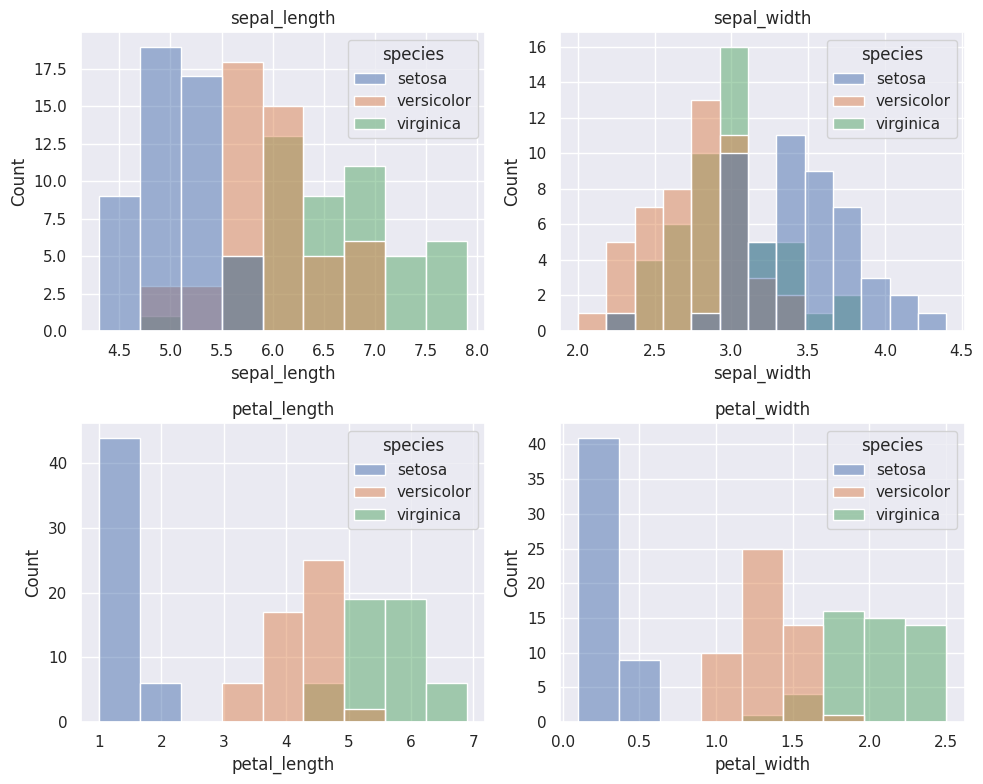

In [6]:
%matplotlib inline
num_cols = df.select_dtypes("number").columns   
# 只取数值列，select_dtypes("number") 筛选 DataFrame 里面所有属于整数、浮点数的列；.columns 取出这些列的名字，保存为列名列表

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), num_cols):   # axes.ravel(),把形状为 (2,2) 的二维 axes 数组，展平成一维序列，得到 [ax0, ax1, ax2, ax3]
    sns.histplot(data=df, x=col, hue="species", ax=ax)
    ax.set_title(col)
fig.tight_layout()
plt.show()

### 图像解读

 1）左上：sepal_length 花萼长度

- setosa (蓝)：大多集中在 4.5‑5.5 ，花萼普遍偏短
- versicolor (橙)：大多 5.0‑6.5
- virginica (绿)：大多 6.0‑7.5，花萼最长
> 三个品种的花萼长度**有一部分重叠**，只看花萼长度不容易完全区分开

 2）右上：sepal_width 花萼宽度
- 三个品种大量混在一起，数值重叠非常严重。
- **花萼宽度是区分能力最差的一个特征，单靠它分不清花的种类。**

 3）左下：petal_length 花瓣长度【最强区分特征】
- setosa (蓝)：花瓣几乎全部集中在 1‑2cm，**很短，完全不和另外两类重叠！**
- versicolor：集中 4‑5cm
- virginica：集中 5‑7cm，花瓣最长
- 只要花瓣长度小于 2 厘米 → 几乎 100% 就是 setosa！

 4）右下：petal_width 花瓣宽度【第二强区分特征】
- 和花瓣长度规律几乎一模一样
- setosa：花瓣宽度 0‑0.5 厘米，非常窄，完全分开
- versicolor：1.0‑1.5
- virginica：1.5‑2.5，花瓣最宽

整张图最重要的结论（机器学习视角）
- **花瓣长度、花瓣宽度（petal_length、petal_width）区分效果极好**, Setosa 和另外两个品种完全分割开，没有重叠，一眼就能识别。
- 花萼长度可以部分区分，但有重叠。
- 花萼宽度几乎区分不开三类鸢尾花

## 4. 单变量分布：箱线图（按类别分组）

**要点**：直方图看整体形状，箱线图看组间差异和异常值——两个视角互补，EDA 里通常都做。

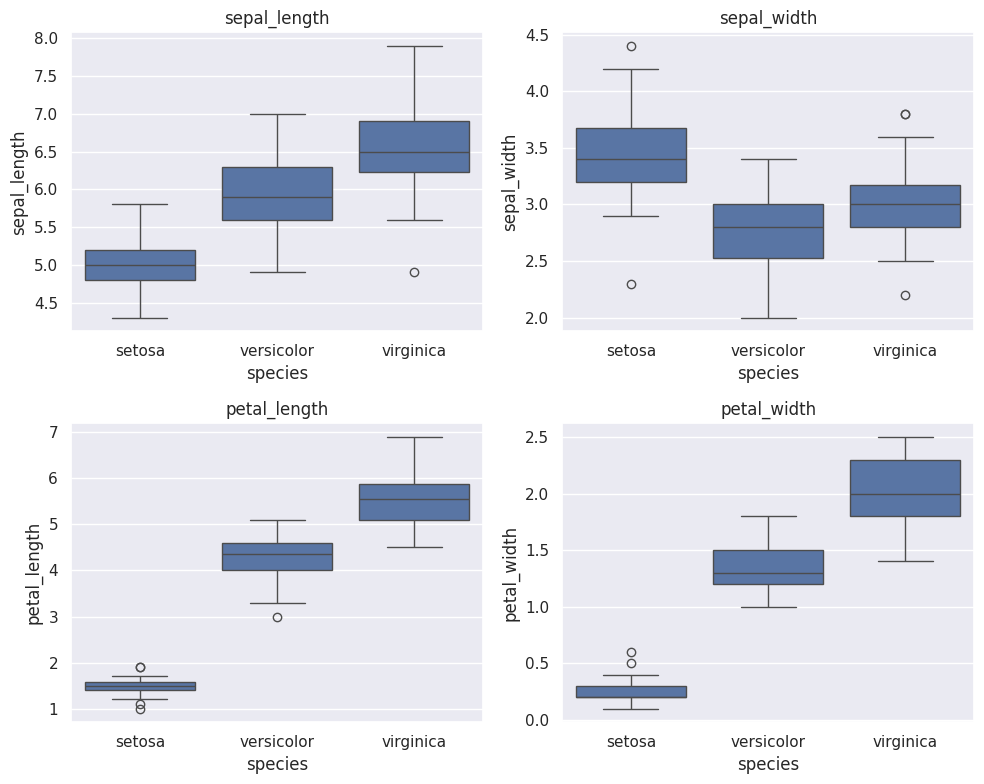

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(col)
fig.tight_layout()
plt.show()

## 图像解读

箱线图（盒须图）基础结构
- 先看懂**单一个箱子代表什么**：
  - **箱子中间那条横线 = 中位数**
    - 一半样本比它大、一半比它小；代表这批数据的中间水平
  - 箱子**上下两条边**
    - 箱子上边：上四分位数 Q3 → 75% 的样本 ≤这个数值
    - 箱子下边：下四分位数 Q1 → 25% 的样本 ≤这个数值
    - 箱子本身这块区间，装着**中间 50% 的数据**
  - 箱子向外延伸出来的两根竖线（须）：正常数据的最大值、最小值
  - **单独的空心圆点 = 异常值（离群点）**，偏离大部分样本的数据

横轴：3 个鸢尾花品种 setosa / versicolor / virginica ; 纵轴：对应特征的厘米数值

**左上**：sepal_length 花萼长度
- setosa：中位数≈5.0，整体花萼最短
- versicolor：中位数≈6.0，中等
- virginica：中位数≈6.5，整体花萼最长
> 三个品种中位数依次升高，但是箱子有重叠，说明部分样本花萼长度混在一起。virginica 下方有 1 个空心圆圈，属于离群样本。

**右上**：sepal_width 花萼宽度
- setosa：中位数≈3.4，**反而宽度最大**
- versicolor：中位数≈2.7，宽度最小
- virginica：中位数≈3.0，中间水平
> 三者箱子大量重叠。**花萼宽度很难用来区分品种**。setosa、versicolor、virginica 都出现了少量离群圆点。

**左下**：petal_length 花瓣长度（区分效果最好）
- setosa：中位数≈1.5，箱子范围 1‑2cm，**和另外两个箱子完全没有重叠！**
- versicolor：中位数≈4.4
- virginica：中位数≈5.6，花瓣最长
- 只要花瓣长度小于 2cm，几乎就一定是 setosa

**右下**：petal_width 花瓣宽度（区分效果第二好）
- setosa：中位数≈0.2，和另外两类完全隔开
- versicolor：中位数≈1.4
- virginica：中位数≈2.0，花瓣最宽

## 5. 双变量关系：pairplot（一次看所有两两组合）

**要点**：pairplot 对角线=单变量分布（这里用 KDE 密度曲线），非对角线=两两散点图。一眼看出哪些特征组合可分——Iris 里 setosa 和另外两类几乎完全不重叠。这是 EDA 首选武器，生信里看基因表达关系同理。

/home/wsl2/anaconda3/envs/dl/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


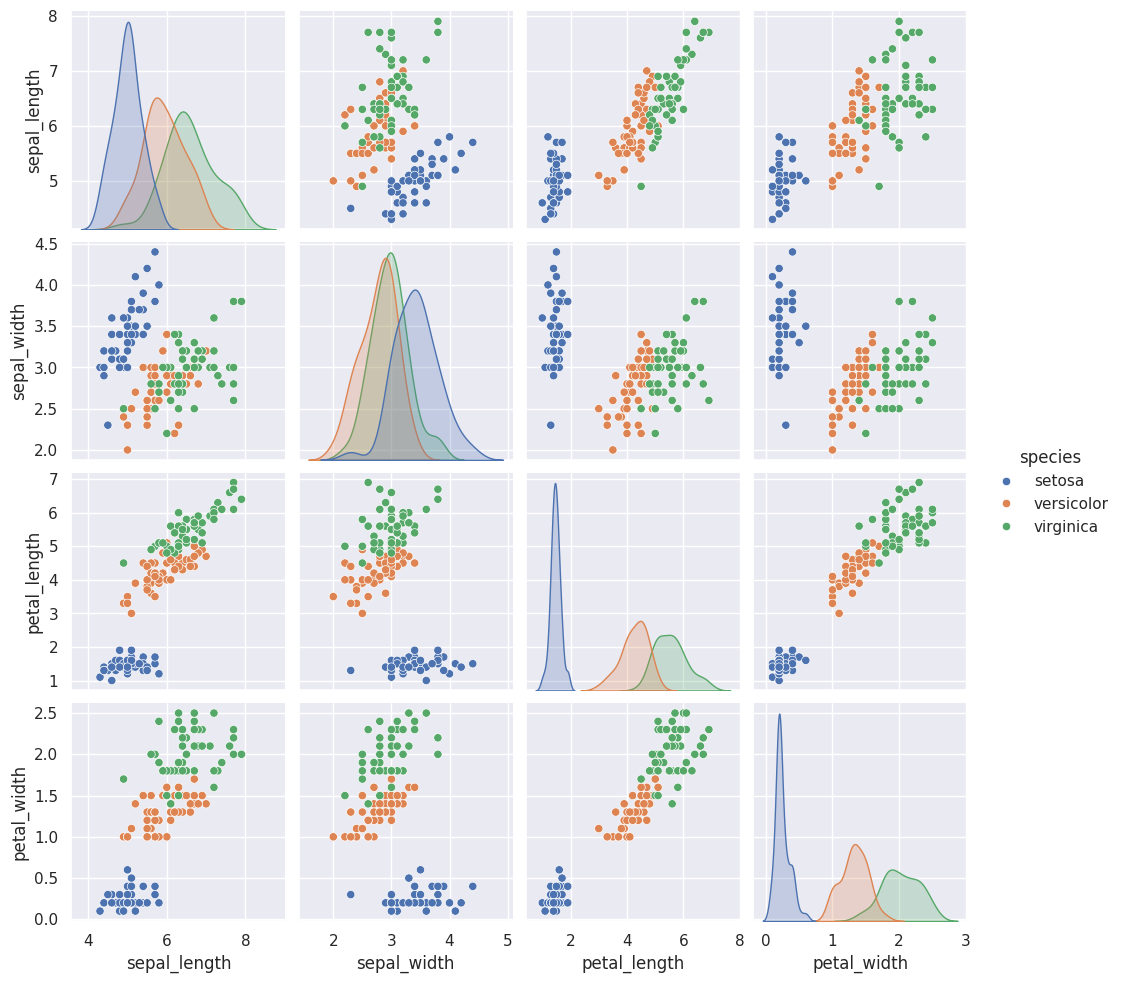

In [6]:
sns.pairplot(df, hue="species", diag_kind="kde")   # diag_kind="kde" 对角线绘制内容:平滑密度曲线;diag_kind="hist" 对角线绘制内容:直方图
plt.show()

## 图像解读

配对图 pairplot（散点矩阵图）网格布局规则
- **对角线（左上→右下）：平滑密度曲线 (KDE 图)**
  - 单独展示**单个特征自己的分布**，和之前看的直方图含义一致。
  - 每条颜色曲线代表一个品种。
- **非对角线格子：二维散点图**
  - 每一张小图 = 两个特征的对比：
    - 横轴：这一列底部标注的特征
    - 纵轴：这一行左侧标注的特征
    - 每个圆点 = 一朵鸢尾花样本
    - 颜色：蓝色‑setosa，橙色‑versicolor，绿色‑virginica
> 上三角、下三角是对称的，只是 x,y 轴反过来

分区详细解读
- 对角线（密度曲线）
  -  sepal_length：三个品种分布有重叠
  -  sepal_width：重叠程度很高
  -  petal_length：**蓝色 setosa 曲线完全分开**，和另外两类没有交集
  -  petal_width：setosa 同样完全独立

重点看散点（非对角线格子）
- 1. petal_length & petal_width（花瓣长度 × 花瓣宽度）
  - 也就是第 3 行第 4 列 / 第 4 行第 3 列的散点图
  - **三个品种几乎分成 3 坨完全分开的点簇！**
  - 蓝色点一簇、橙色一簇、绿色一簇，边界清晰。
  - 说明**花瓣长、花瓣宽两个特征组合在一起，分类效果最好**。
- 2. sepal_length & sepal_width（花萼长 × 花萼宽）
  - 第 1 行第 2 列：
  - 三个颜色的点大量混在一起，边界模糊。
  - 只用花萼长宽，很难区分 versicolor 和 virginica。
- 3. petal_length × sepal_length
  - 第 3 行第 1 列：
  - 蓝色 setosa 点明显跑到左下角，和另外两类分离；橙色、绿色仍有一点点重叠。

整张图得出的核心结论
-  **花瓣特征（petal_length、petal_width）区分能力最强**，setosa 可以被轻松分开；versicolor、virginica 也分得比较开
- sepal_length（花萼长）有一定区分能力，但是存在重叠
- sepal_width（花萼宽）区分效果最差，三个品种混在一起
- 机器学习分类任务：
  - 优先选用 `petal_length` + `petal_width` 作为训练特征，效果最优

识别小技巧
- 如果**同颜色的点紧紧聚成一团，不同颜色之间空隙很大** → 这组特征区分效果好
- 如果不同颜色的圆点互相穿插、混在一起 → 特征区分效果差

## 6. 相关性热力图

**要点**：corr() 计算皮尔逊相关系数；热力图一眼看出哪些特征冗余（高度相关）——建模前先看这一步，可以决定要不要删冗余特征。

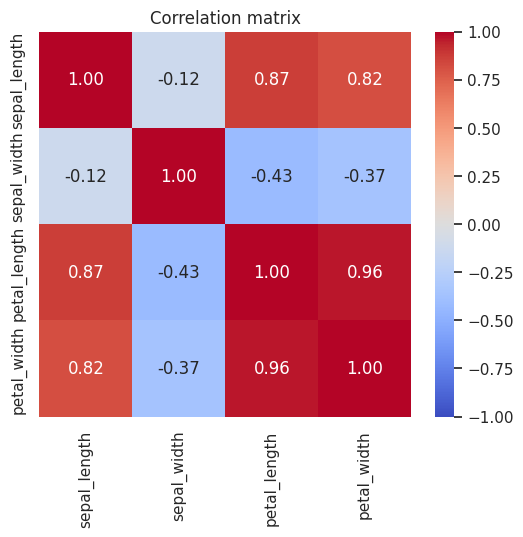

In [7]:
corr = df.select_dtypes("number").corr()   # .corr():计算皮尔逊相关系数矩阵,求两个变量之间线性相关程度
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix")
plt.show()

## 图像解读

看图规则
1. **右侧色条**
   - 🔴红色：**正相关**（一个变量变大，另一个也变大），越红越接近 1，相关性越强
   - 🔵蓝色：**负相关**（一个变量变大，另一个变小），越蓝越接近‑1
   - 接近白色 / 浅灰：数值≈0，几乎无线性关系
2. 格子内数字 = **皮尔逊相关系数 r**，范围 [-1, 1]
3. 对角线全部是 1.00 ：特征和自己完全相关，永远深红色

|变量组合	|相关系数|	结论|
|--|--|--|
|sepal_length & sepal_width	|‑0.12	|几乎无相关，微弱负相关，可以忽略
|sepal_length & petal_length|	0.87	|强正相关，花萼越长，花瓣倾向于越长
|sepal_length & petal_width|	0.82	|强正相关，花萼越长，花瓣越宽
|sepal_width & petal_length|‑0.43	|中等强度负相关，花萼越宽，花瓣长度轻微变短
|sepal_width & petal_width	|‑0.37	|中等负相关
|petal_length & petal_width|	0.96	|极强正相关！！花瓣越长，花瓣几乎一定越宽。

和前面散点图 pairplot 对应验证
- 之前 pairplot 图中 petal_length‑petal_width 的点沿着一条斜线紧密聚集，就是**0.96 高相关**的可视化表现，二者高度绑定
- petal_length 和 petal_width **高度多重共线性**
> 两个信息高度重复！建模的时候如果你两个同时放进模型，属于冗余特征。可以只保留其中 1 个即可，减少特征数量
- sepal_width 和花瓣特征是负相关，和花萼长度几乎没关系，属于一个相对独立的特征。
- 花瓣、花萼长度为强正相关。

## 7. 输出结论 + 保存

**要点**：EDA 的产出不是图本身，而是**从图里读出的结论**。每张图配一句结论（可分/相关/异常），才构成汇报材料。

**从上面图中读出的结论（示例）**：
1. setosa 的三个花瓣/花萼特征与另外两类几乎不重叠 → 可分性极强；
2. petal_length 与 petal_width 相关性约 0.96 → 冗余特征，建模时二选一即可；
3. 未发现明显异常值（箱线图须外点很少）。

**保存图**：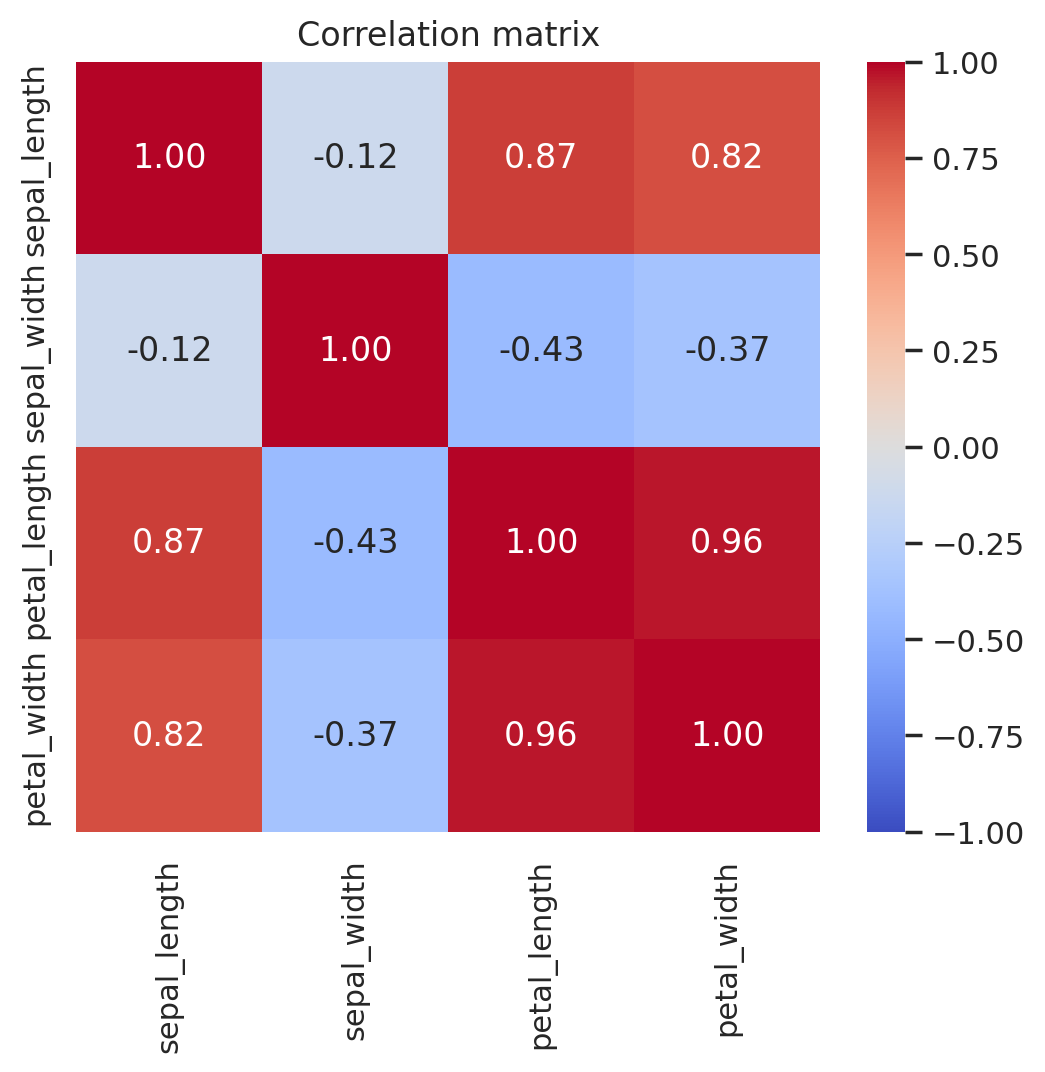

In [8]:
# 保存上一步的热力图（示例）
fig.savefig("iris_corr.png", dpi=200, bbox_inches="tight", facecolor="white")
# 论文/汇报用：fig.savefig("iris_corr.pdf")  矢量格式

## 8. 项目自测题

1.拿到新数据，前三步必做什么？为什么先查缺失值再画图？
- 完整三步：shape（规模）→ info()（类型+非空）→ isna().sum() + describe()（缺失+范围）;如果不先查缺失值、做处理，那么画图的时候会出错，很有可能会呈现错误的图像

2.pairplot 的对角线和非对角线分别是什么？diag_kind="kde" 改了什么？
- 对角线=单变量分布，非对角线=两两散点图；diag_kind="kde" 改变了对角线图像的形式，这里变为了平滑密度曲线

3.petal_length 和 petal_width 相关性 0.96 意味着什么？建模前看 corr() 有什么实际价值？
- 意味着二者高度相关，在做分析时只用看其中一个；可以看出那些高度相关的特征，然后选择是否选择删除冗余来分析数据

4.如果 df 里有非数值列，直接 df.corr() 会怎样？select_dtypes("number") 解决了什么？
对于含有非数值列，直接使用会抛出异常代码信号，终止运行；解决了只看数值列的事情，这样就不会报错

5.这个 EDA 流程换到**单细胞表达矩阵**（行=基因，列=细胞，数值是表达量）上：哪一步要改？哪一步能直接复用？（提示：想想 hue 还能用什么）
- 原标准 EDA 流程：
1. 基础探查：`df.info()`、`df.head()`、`df.describe()`
2. 缺失值检查与清洗
3. 单特征可视化：直方图、箱线图
4. `sns.pairplot()`两两散点矩阵
5. 相关性热力图 `.corr()`+`heatmap`

- 单细胞
1. 加载表达矩阵 + **细胞元数据（metadata，存放 hue 标签）**
2. 计算质控指标：每个细胞 UMI 总数、基因数、线粒体比例
3. 质控指标可视化（hist/boxplot，代码复用旧 seaborn）
4. 过滤低质量细胞、低表达基因（清洗）
5. 归一化、对数转换
6. 降维 PCA → UMAP/t‑SNE
7. 降维散点图，使用`hue`展示细胞分组
8. 标记基因可视化（小提琴图、点图）
9. 少量目标基因的相关性热力图